<a href="https://colab.research.google.com/github/greeshmakrishnan00/EDA-ML-DL-Projects/blob/main/AI_POWERED_CUSTOMER_SUPPORT_CHATBOT_USING_RETRIEVAL_AUGMENTED_GENERATION_(RAG)_PROJECT_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#
Problem Statement
With Resolution_Status as the prediction variable, the task involves using customer support ticket information to predict whether a ticket will be Resolved, Pending, or Escalated.

The objective is to build an AI-powered customer support analytics system that can analyze ticket details, customer interactions, response times, satisfaction levels, and support channels to predict ticket outcomes. Accurate prediction of ticket resolution status can help organizations improve customer satisfaction, optimize resource allocation, reduce response times, and enhance support efficiency.

This project applies Machine Learning and Deep Learning techniques to classify support tickets into multiple resolution categories based on historical customer support data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [ ]:
df=pd.read_csv('/content/AI_Powered_Customer_Support_RAG_Realistic_10000.csv')
df

,ticket_id,customer_id,company,industry,query_category,priority,resolution_status,response_time_minutes,customer_satisfaction,chatbot_handled,sentiment
0,TKT100001,CUST50001,Accenture,Healthcare,Product Inquiry,Low,Resolved,27,9,No,Positive
1,TKT100002,CUST50002,IBM,Education,Refund Request,Low,Resolved,34,8,Yes,Positive
2,TKT100003,CUST50003,Google,Insurance,Refund Request,Low,Resolved,53,9,Yes,Positive
3,TKT100004,CUST50004,HCL,Insurance,Refund Request,High,Resolved,48,9,Yes,Positive
4,TKT100005,CUST50005,Infosys,Insurance,Billing,Low,Resolved,8,7,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...
9995,TKT109996,CUST59996,IBM,E-Commerce,Account Access,Low,Resolved,34,9,Yes,Positive
9996,TKT109997,CUST59997,IBM,Insurance,Payment Failure,Low,Pending,63,7,Yes,Neutral
9997,TKT109998,CUST59998,HCL,Healthcare,Billing,Low,Resolved,58,10,Yes,Positive
9998,TKT109999,CUST59999,Wipro,Education,Refund Request,Low,Resolved,8,10,Yes,Neutral


In [ ]:
df.shape

(10000, 11)

In [ ]:
df.columns

Index(['ticket_id', 'customer_id', 'company', 'industry', 'query_category',
       'priority', 'resolution_status', 'response_time_minutes',
       'customer_satisfaction', 'chatbot_handled', 'sentiment'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
ticket_id,0
customer_id,0
company,0
industry,0
query_category,0
priority,0
resolution_status,0
response_time_minutes,0
customer_satisfaction,0
chatbot_handled,0


In [ ]:
target='resolution_status'

In [ ]:
df[target].value_counts()

,count
resolution_status,
Resolved,6030
Pending,2476
Escalated,1494


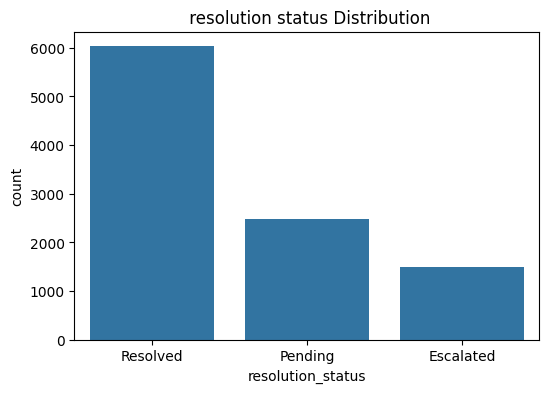

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=target,data=df)
plt.title(" resolution status Distribution")
plt.show()

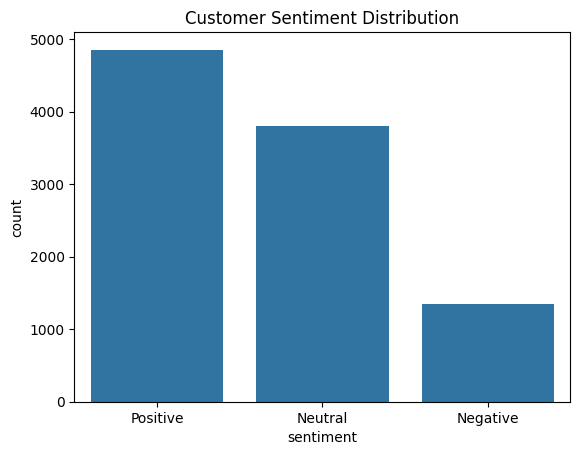

In [ ]:
sns.countplot(x='sentiment', data=df)
plt.title('Customer Sentiment Distribution')
plt.show()

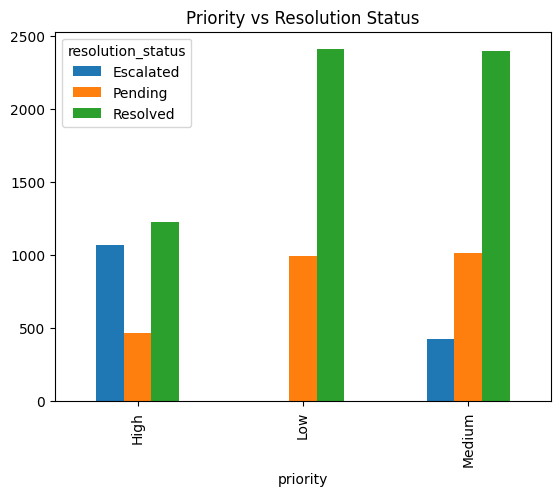

In [ ]:
pd.crosstab(df['priority'],
            df['resolution_status']).plot(kind='bar')
plt.title('Priority vs Resolution Status')
plt.show()

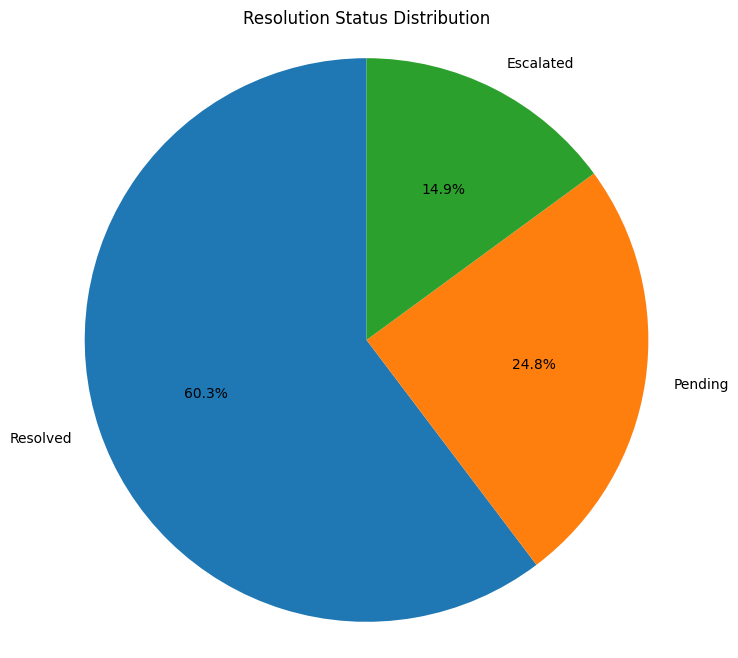

In [ ]:
import matplotlib.pyplot as plt

status_counts = df['resolution_status'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Resolution Status Distribution')
plt.axis('equal')
plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['ticket_id', 'customer_id', 'company', 'industry', 'query_category',
       'priority', 'resolution_status', 'chatbot_handled', 'sentiment'],
      dtype='object')

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['response_time_minutes', 'customer_satisfaction'], dtype='object')

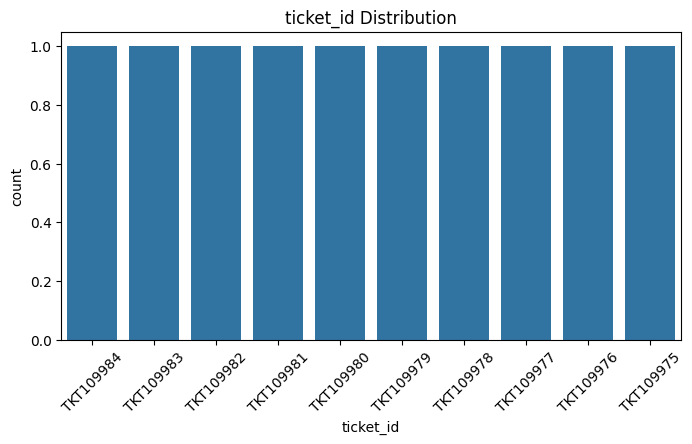

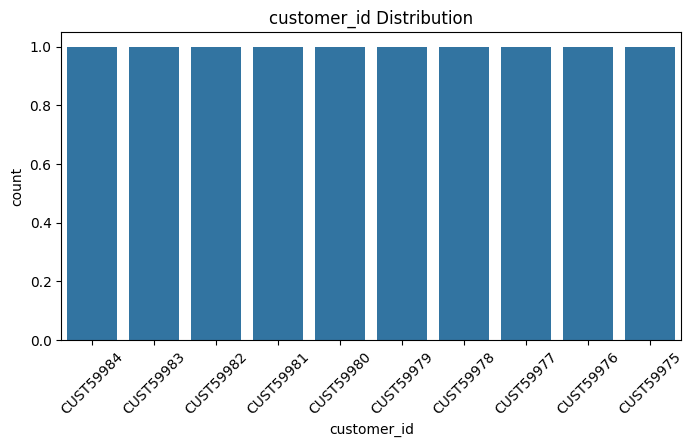

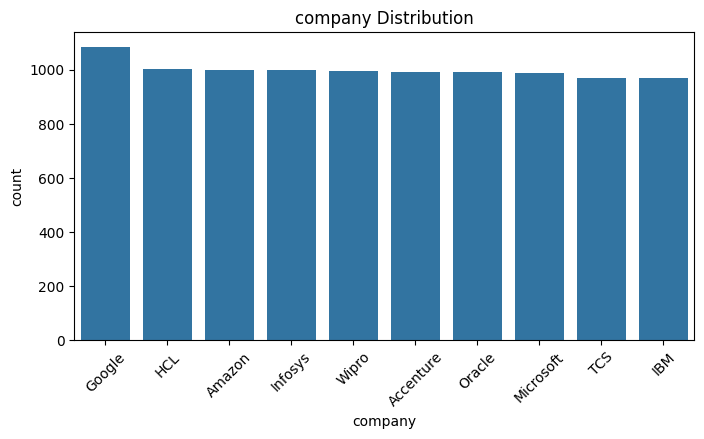

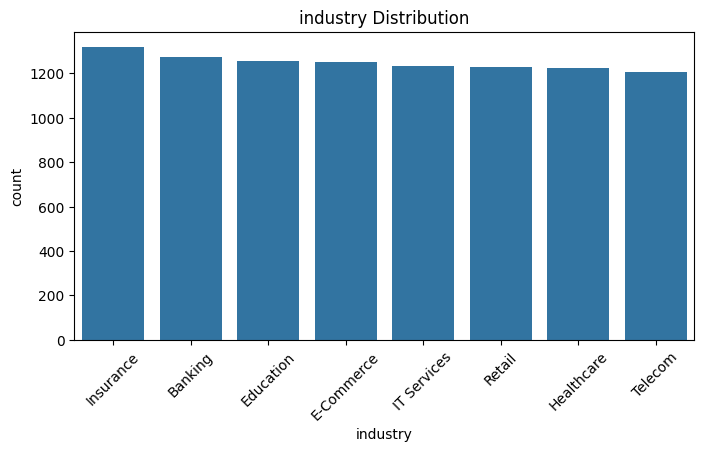

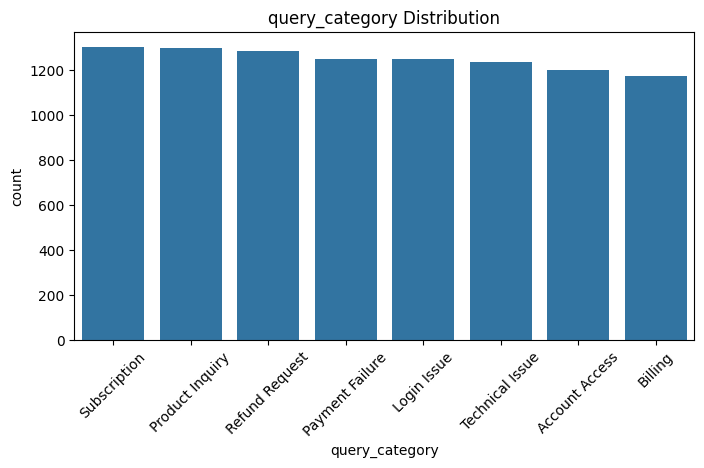

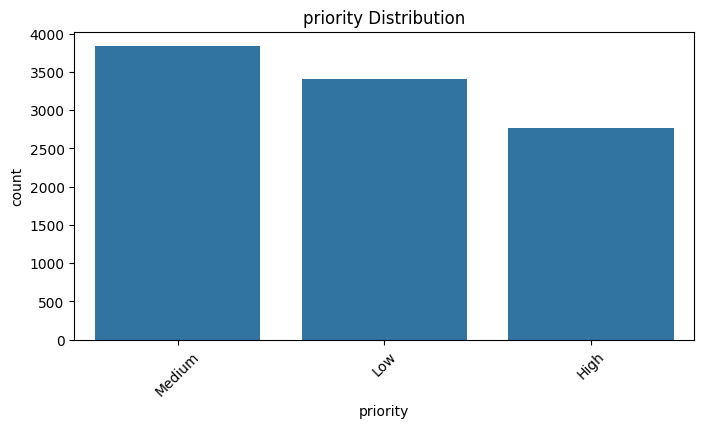

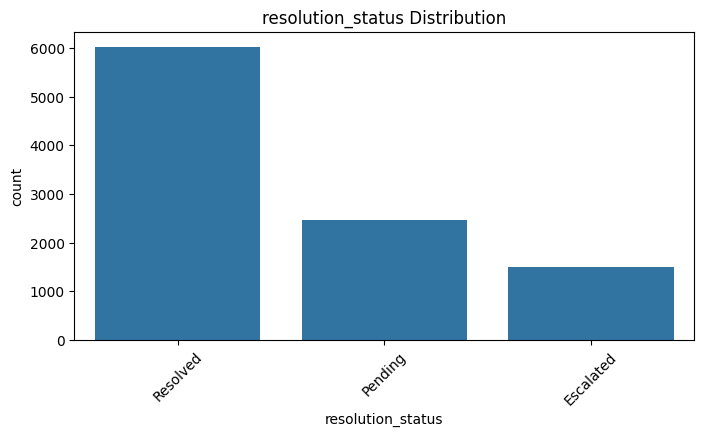

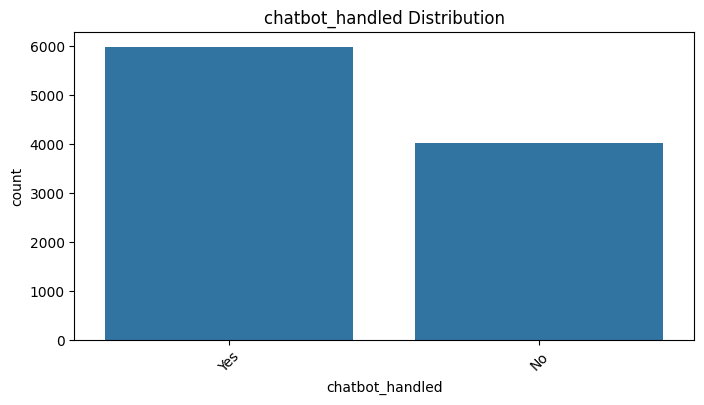

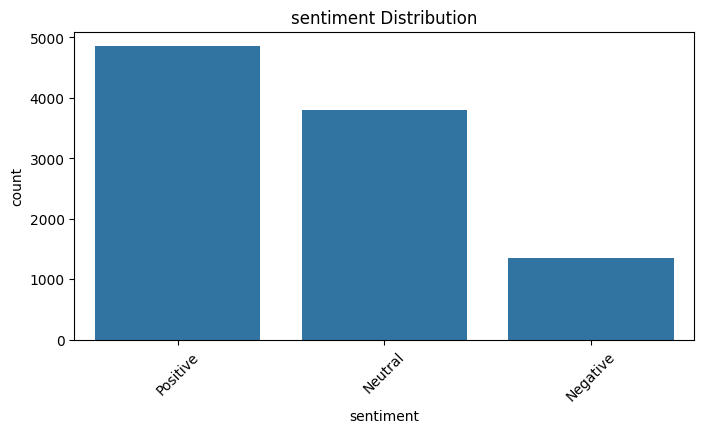

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
    plt.xticks(rotation=45)
    plt.title(f'{col} Distribution')
    plt.show()

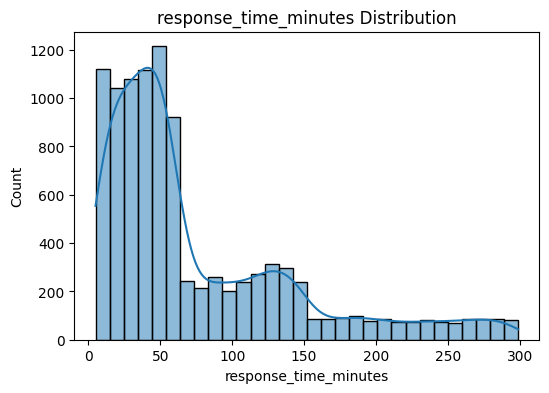

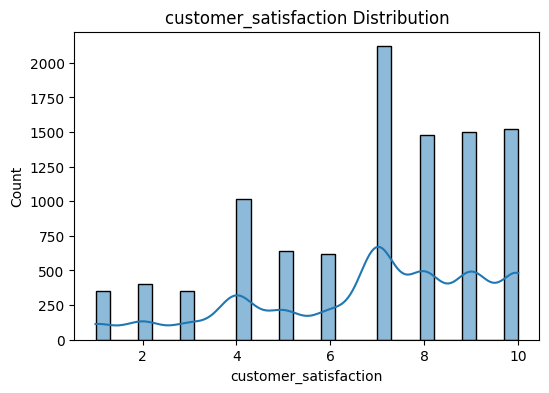

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],bins=30,kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in categorical_cols:
    df[col]=le.fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   ticket_id              10000 non-null  int64
 1   customer_id            10000 non-null  int64
 2   company                10000 non-null  int64
 3   industry               10000 non-null  int64
 4   query_category         10000 non-null  int64
 5   priority               10000 non-null  int64
 6   resolution_status      10000 non-null  int64
 7   response_time_minutes  10000 non-null  int64
 8   customer_satisfaction  10000 non-null  int64
 9   chatbot_handled        10000 non-null  int64
 10  sentiment              10000 non-null  int64
dtypes: int64(11)
memory usage: 859.5 KB


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

# Features and Target
x = df.drop('resolution_status', axis=1)
y = df['resolution_status']

# Apply SMOTE
smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

# Combine X and Y into one DataFrame
df_resampled = pd.concat(
    [pd.DataFrame(x_resampled, columns=x.columns),
     pd.DataFrame(y_resampled, columns=['resolution_status'])],
    axis=1
)

# Display balanced dataset
print(df_resampled.head())

# Check class distribution
print(df_resampled['resolution_status'].value_counts())

   ticket_id  customer_id  company  industry  query_category  priority  \
0          0            0        0         3               4         1   
1          1            1        4         2               5         1   
2          2            2        2         5               5         1   
3          3            3        3         5               5         0   
4          4            4        5         5               1         1   

   response_time_minutes  customer_satisfaction  chatbot_handled  sentiment  \
0                     27                      9                0          2   
1                     34                      8                1          2   
2                     53                      9                1          2   
3                     48                      9                1          2   
4                      8                      7                1          2   

   resolution_status  
0                  2  
1                  2  
2          

In [ ]:
df=df_resampled

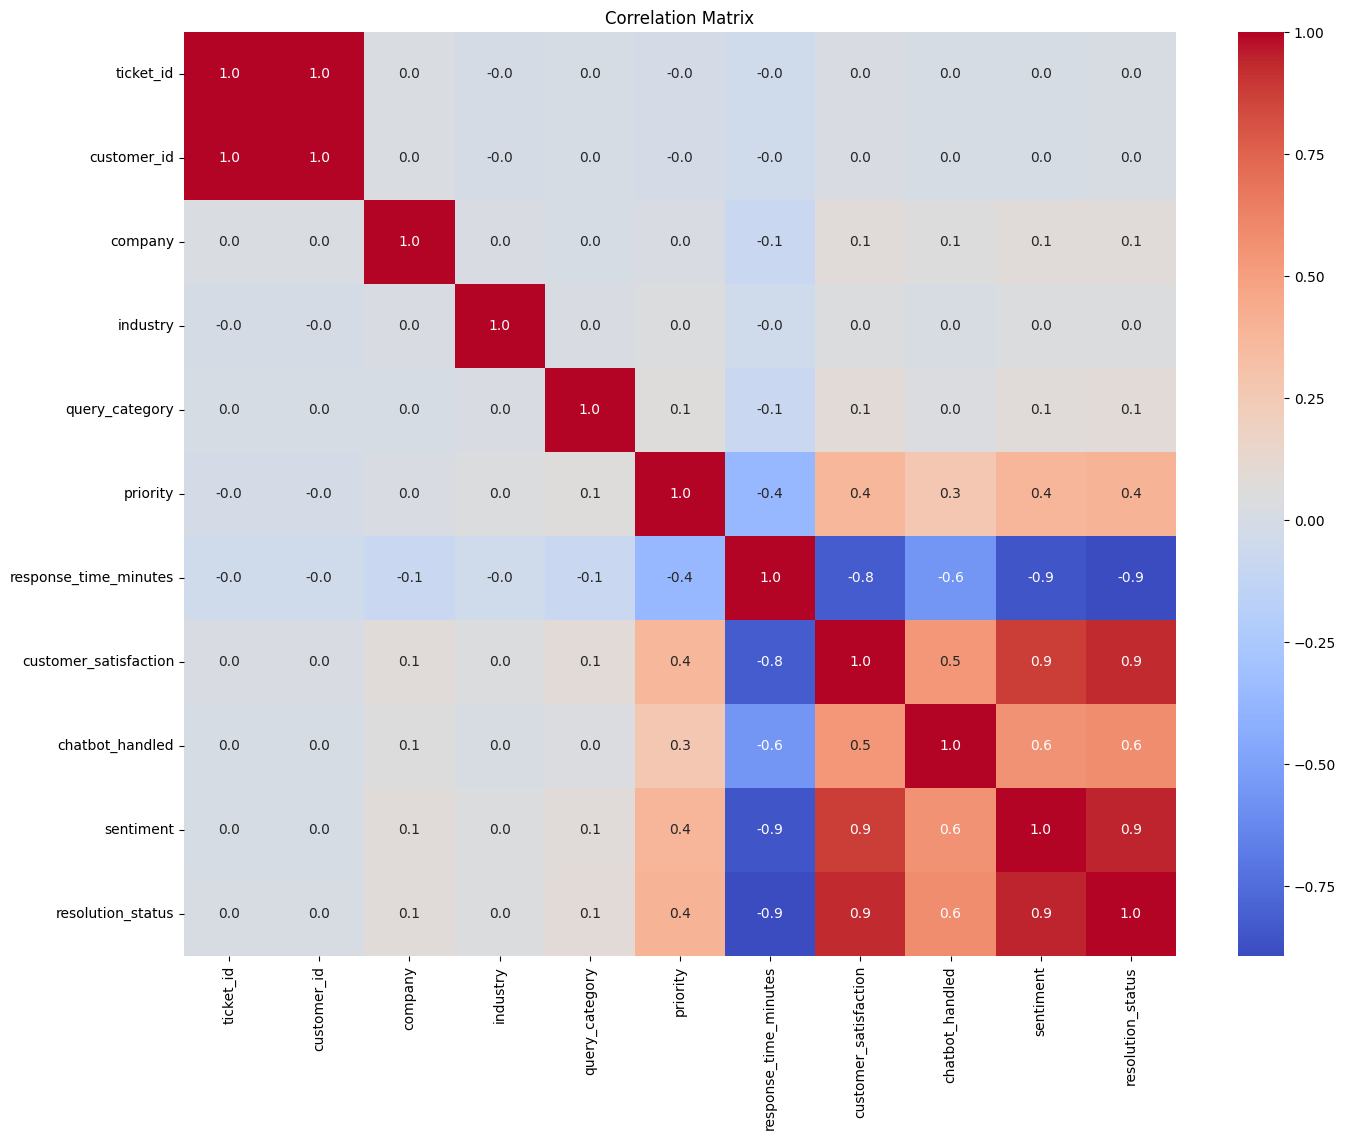

In [ ]:
core_matrix=df.corr()
plt.figure(figsize=(16,12))
sns.heatmap(core_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.drop(["sentiment","response_time_minutes"],axis=1,inplace=True)

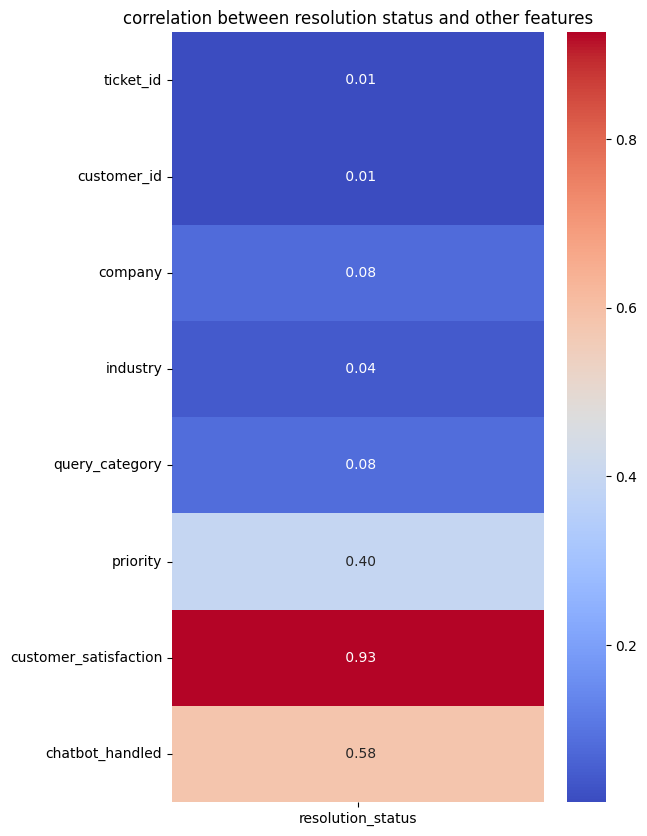

In [ ]:
plt.figure(figsize=(6,10))

status_corr=df.corr()["resolution_status"]
status_corr=status_corr.drop("resolution_status")
sns.heatmap(status_corr.to_frame(), annot=True,fmt=' .2f',cmap='coolwarm',cbar=True, annot_kws={'size':10})
plt.title('correlation between resolution status and other features')
plt.show()

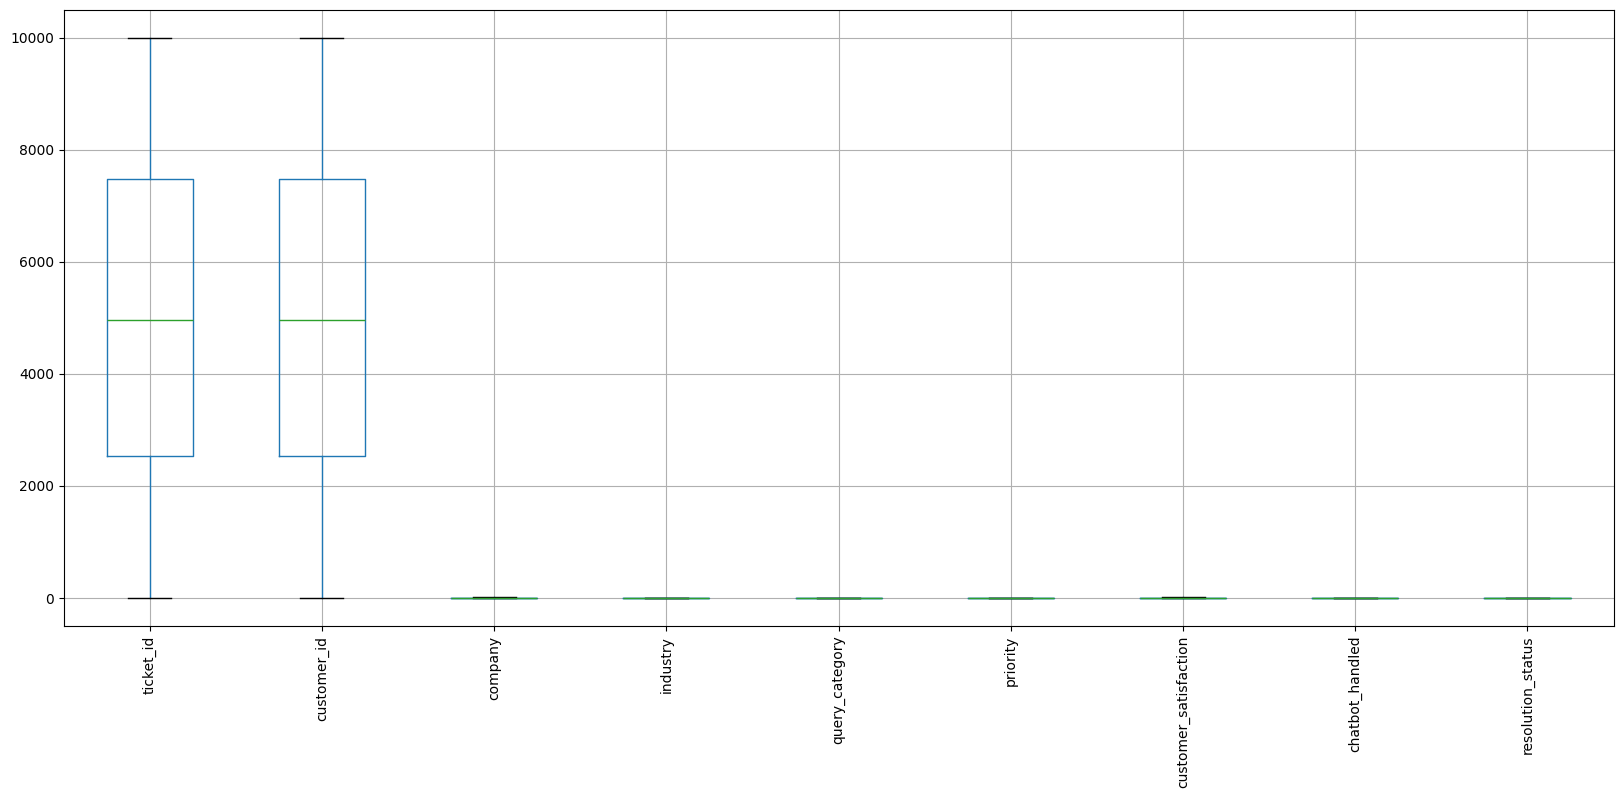

In [ ]:
df.boxplot(figsize=(20,8))
plt.xticks(rotation=90)
plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df
df=remove_outliers_iqr(df,exclude_column=target)

In [ ]:
df.shape

(18090, 9)

In [ ]:
df.columns

Index(['ticket_id', 'customer_id', 'company', 'industry', 'query_category',
       'priority', 'customer_satisfaction', 'chatbot_handled',
       'resolution_status'],
      dtype='object')

In [ ]:
features=['ticket_id', 'customer_id', 'company', 'industry', 'query_category',
       'priority', 'customer_satisfaction', 'chatbot_handled']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
x=df[['ticket_id', 'customer_id', 'company', 'industry', 'query_category',
       'priority', 'customer_satisfaction', 'chatbot_handled']]
y=df["resolution_status"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.73


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Machine Learning

In [ ]:
#DecisionTree

from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.93


In [ ]:
# SVC

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

# Train
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Pipeline Linear SVC Accuracy: {accuracy:.2f}")

Pipeline Linear SVC Accuracy: 0.93


In [ ]:
#Random forest

from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.94


In [ ]:
#GradientBooster

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9356621711253593


In [ ]:
# ADABOOST
from sklearn.ensemble import AdaBoostClassifier

model=AdaBoostClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.92


In [ ]:
#xgboost

from  xgboost import XGBClassifier

model=XGBClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.94


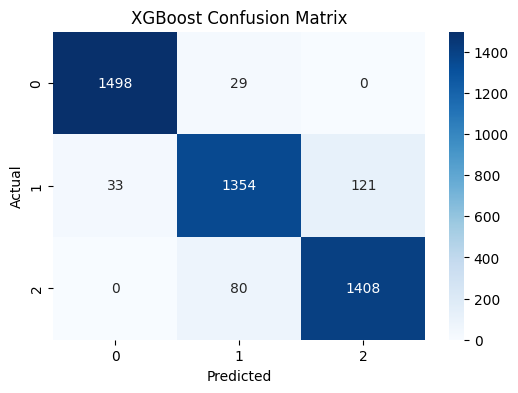

In [ ]:
#Confusion Matrix

cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

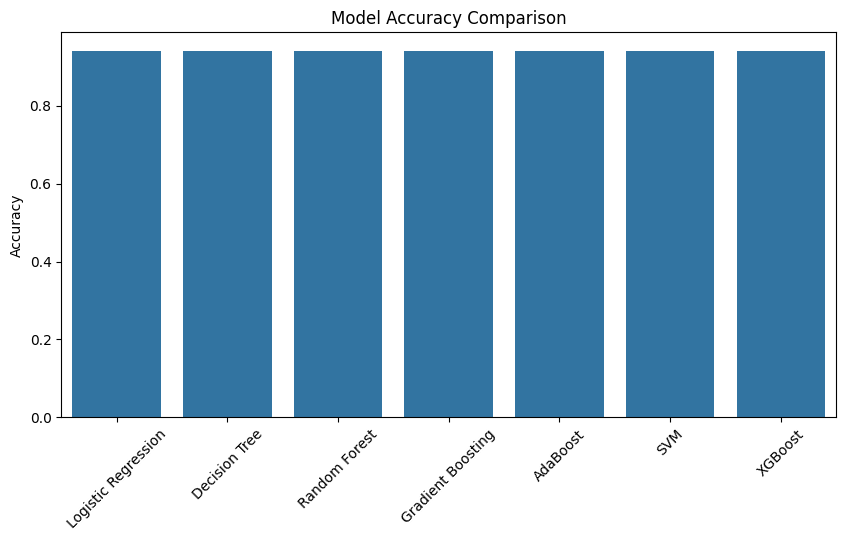

In [ ]:
models=[
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'AdaBoost',
    'SVM',
    'XGBoost']

accuracies=[
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred)]

plt.figure(figsize=(10,5))

sns.barplot(x=models,y=accuracies)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# K-Fold Cross Validation

In [ ]:
X=df.drop('resolution_status',axis=1)
y=df['resolution_status']

kf=KFold(n_splits=5,shuffle=True,random_state=42)

model=LogisticRegression(max_iter=10000)

best_accuracy=0
best_fold=-1

best_x_train=None
best_y_train=None
best_x_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):

    print(f"\nFold {fold}")

    x_train,x_test=x.iloc[train_index],x.iloc[test_index]
    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    model.fit(x_train,y_train)

    y_pred=model.predict(x_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc
        best_fold=fold

        best_X_train=x_train
        best_y_train=y_train

        best_X_test=x_test
        best_y_test=y_test

        best_y_pred=y_pred

print(f"\nBest Fold: {best_fold} with Accuracy: {best_accuracy}")


Fold 1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9303482587064676

Fold 2


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9389165284687673

Fold 3


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9342177998894416

Fold 4


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9284134881149807

Fold 5
Accuracy: 0.9344941956882256

Best Fold: 2 with Accuracy: 0.9389165284687673


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model=LogisticRegression(max_iter=10000)
model.fit(best_X_train,best_y_train)
print("Logistic Regression:",model.score(best_X_test,best_y_test))

Logistic Regression: 0.9389165284687673


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
print("Random Forest:",model.score(best_X_test,best_y_test))

Random Forest: 0.9449972360420121


In [ ]:
model=DecisionTreeClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Decision Tree:",model.score(best_X_test,best_y_test))

Decision Tree: 0.9344941956882256


In [ ]:
model=SVC()
model.fit(best_X_train,best_y_train)
print("SVM:",model.score(best_X_test,best_y_test))

SVM: 0.32808181315644


In [ ]:
model=GradientBoostingClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Gradient Boosting:",model.score(best_X_test,best_y_test))

Gradient Boosting: 0.9455500276395798


In [ ]:
model=AdaBoostClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("AdaBoost:",model.score(best_X_test,best_y_test))

AdaBoost: 0.8709231619679381


In [ ]:
model=XGBClassifier(eval_metric='logloss',random_state=42)
model.fit(best_X_train,best_y_train)
print("XGBoost:",model.score(best_X_test,best_y_test))

XGBoost: 0.9438916528468767


#Deep Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the training and testing data for deep learning
x_train_scaled_dl = scaler.fit_transform(best_X_train)
x_test_scaled_dl = scaler.transform(best_X_test)

# Convert best_y_train to a numpy array for TensorFlow
best_y_train_np = best_y_train.to_numpy()
best_y_test_np = best_y_test.to_numpy()

model=Sequential()
model.add(Dense(256,input_shape=(x_train_scaled_dl.shape[1],),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))

model.add(Dense(3, activation='softmax'))

model.compile(optimizer=Adam(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.fit(x_train_scaled_dl,best_y_train_np,epochs=100, verbose=0) # verbose=0 to suppress output for each epoch

y_pred_raw=model.predict(x_test_scaled_dl)
y_pred=tf.argmax(y_pred_raw, axis=1).numpy()

print(f'\nAccuracy: {accuracy_score(best_y_test_np,y_pred)}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Accuracy: 0.925649530127142


#Conclusion

The AI-Powered Customer Support Chatbot Using Retrieval Augmented Generation (RAG) project successfully predicted customer support ticket resolution status as Resolved, Pending, or Escalated using various Machine Learning and Deep Learning algorithms. Among all models, Gradient Boosting achieved the highest accuracy of 94.56%, followed closely by Random Forest (94.50%), XGBoost (94.39%), and Logistic Regression (93.89%), demonstrating excellent predictive performance. The Deep Learning model also performed well with an accuracy of 92.56%, while SVM showed comparatively poor performance at 32.81%. The results indicate that features such as response time, customer satisfaction, sentiment, priority level, and chatbot handling play a significant role in determining ticket outcomes. This project demonstrates the effectiveness of AI-driven analytics in improving customer support operations, enhancing customer satisfaction, optimizing resource allocation, and reducing resolution delays. Based on the experimental results, Gradient Boosting is the most suitable model for deployment due to its superior accuracy and reliability. Future work can focus on incorporating real-time support data, advanced NLP techniques, and enhanced RAG-based capabilities to further improve prediction accuracy and intelligent customer service automation.


# Future Scope

Future enhancements of this project can focus on integrating real-time customer support data, advanced Natural Language Processing (NLP), and Generative AI technologies to improve prediction accuracy and customer experience. The system can be extended with Retrieval Augmented Generation (RAG) to provide intelligent, context-aware responses by retrieving relevant information from knowledge bases and support documents. Additional features such as multilingual support, voice-based customer interactions, sentiment-aware response generation, and personalized recommendations can further enhance chatbot performance. Incorporating streaming data analytics, automated ticket prioritization, and cloud-based deployment can improve scalability and operational efficiency. Future research may also explore transformer-based deep learning models, large language models (LLMs), and reinforcement learning techniques to create more adaptive and intelligent customer support systems.
